<h1 style="font-family: 'Times New Roman'; text-align: center;"><b>End-to-End Real Estate Analysis For Karachi</b></h1>
<h2 style="font-family: 'Times New Roman'; text-align: center; color:#555;">Historical Snapshot (2018–2019) &amp; Affordability Timeline (2019–2026)</h2>

<hr>

<div style="font-family: Arial;;color: green; font-size: 15px; background-color:#f9f9f9; padding:18px; border-left: 5px solid #2196F3; border-radius:4px;"><i>
<b>Executive Summary</b><br><br>
This project analyses <b>45,223 property listings</b> from Zameen.com covering Karachi's For Sale market from
<b>August 2018 to July 2019</b>. Using Python, SQL window functions, and Power BI, it maps price patterns
across <b>17 reliable areas</b>, quantifies an affordability crisis using historically correct salary benchmarks,
and crucially,extends that analysis to <b>2026</b> using Pakistan CPI data and current wage estimates
to show how dramatically the affordability gap has widened over seven years of inflation.<br><br>
<b>Core findings:</b> At 2019 salary levels (PKR 22,000/month), the median Karachi property required
<b>47 years</b> of gross salary to purchase — a housing crisis even before inflation hit.
By 2026, after a ~143% cumulative price level increase, the same property requires roughly
<b>59 years</b> of a PKR 43,000/month salary. Pakistan's salary growth (~95% since 2019) has
not kept pace with property-level inflation, meaning real affordability has deteriorated further
for the urban middle class.
</i></div>

<h2 style="font-family: 'Times New Roman';"><b>1. Import Libraries</b></h2>

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook")

<h2 style="font-family: 'Times New Roman';"><b>2. Data Gathering</b></h2>

In [2]:
real_estate=pd.read_csv('../data/raw/raw_listings.csv')

In [3]:
real_estate = real_estate[ (real_estate['city'].str.lower() == 'karachi') & (real_estate['purpose'] == 'For Sale')].copy()

<h3 style="font-family: 'Times New Roman'; color: red;"><b>Data Assessment</b></h3>

-----------------------------------
<p style="font-family: 'Arial';color: black; font-size:16px;"><i><b>Goal: Understand the structure, types, nulls, and issues of every dataset before touching any values.</i></b></p>

---

In [4]:
#Check shpae
real_estate.shape

(46669, 17)

In [5]:
#Check columns
real_estate.columns.tolist()

['property_id',
 'location_id',
 'page_url',
 'property_type',
 'price',
 'location',
 'city',
 'province_name',
 'latitude',
 'longitude',
 'baths',
 'area',
 'purpose',
 'bedrooms',
 'date_added',
 'agency',
 'agent']

In [6]:
#First Look
real_estate.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
156,86575,6649,https://www.zameen.com/Property/faisal_cantonm...,House,450000000,Cantt,Karachi,Sindh,24.889395,67.098627,7,4 Kanal,For Sale,6,6/20/2019,Premier Properties,Aamir Motiwala
157,342005,232,https://www.zameen.com/Property/karachi_gulist...,House,35000000,Gulistan-e-Jauhar,Karachi,Sindh,24.914988,67.138702,8,16 Marla,For Sale,6,7/18/2019,NaN,NaN
158,466607,1484,https://www.zameen.com/Property/d_h_a_dha_phas...,Flat,21000000,DHA Defence,Karachi,Sindh,24.814367,67.072083,3,8.9 Marla,For Sale,3,10/20/2018,NaN,NaN
159,678919,9594,https://www.zameen.com/Property/malir_malir_ka...,House,6500000,Malir,Karachi,Sindh,24.882302,67.184677,1,3.2 Marla,For Sale,2,3/10/2019,NaN,NaN
160,813506,6732,https://www.zameen.com/Property/surjani_town_s...,House,13000000,Gadap Town,Karachi,Sindh,25.018156,67.066864,4,9.6 Marla,For Sale,4,7/18/2019,NaN,NaN


In [7]:
#Random sample
real_estate.sample(6,random_state=42)

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
49111,15321969,10016,https://www.zameen.com/Property/bahria_town_ka...,Flat,7500000,Bahria Town Karachi,Karachi,Sindh,25.047400,67.313864,3,5.1 Marla,For Sale,2,3/19/2019,Time Properties,Hassan
38365,14611769,6902,https://www.zameen.com/Property/gulshan_e_iqba...,Flat,12000000,Gulshan-e-Iqbal Town,Karachi,Sindh,24.889589,67.061180,3,6 Marla,For Sale,3,6/5/2019,NaN,NaN
40438,14750288,1484,https://www.zameen.com/Property/d_h_a_dha_phas...,House,34000000,DHA Defence,Karachi,Sindh,24.821639,67.071691,4,4 Marla,For Sale,3,3/18/2019,Estate Era,Estate Era
79058,16503341,6884,https://www.zameen.com/Property/gulzar_e_hijri...,Upper Portion,7500000,Gulshan-e-Iqbal Town,Karachi,Sindh,24.951550,67.109420,3,5.1 Marla,For Sale,3,6/14/2019,Deebaj Real Estate,Umar naseer
107004,16963469,10019,https://www.zameen.com/Property/bahria_town_ka...,House,11000000,Bahria Town Karachi,Karachi,Sindh,25.065275,67.313384,3,8 Marla,For Sale,3,7/2/2019,Land Professional Associate,Rao Riffat Iqbal
147637,17245677,8978,https://www.zameen.com/Property/surjani_town_s...,Flat,1425000,Gadap Town,Karachi,Sindh,25.045686,67.072513,1,2 Marla,For Sale,1,7/12/2019,Al Dinas Enterprises,Anas Qureshi


In [8]:
#Check missing values
real_estate.isnull().sum()



property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           12205
agent            12205
dtype: int64

In [9]:
#Check Datatypes and nulls
real_estate.info()

<class 'pandas.DataFrame'>
Index: 46669 entries, 156 to 168445
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_id    46669 non-null  int64  
 1   location_id    46669 non-null  int64  
 2   page_url       46669 non-null  str    
 3   property_type  46669 non-null  str    
 4   price          46669 non-null  int64  
 5   location       46669 non-null  str    
 6   city           46669 non-null  str    
 7   province_name  46669 non-null  str    
 8   latitude       46669 non-null  float64
 9   longitude      46669 non-null  float64
 10  baths          46669 non-null  int64  
 11  area           46669 non-null  str    
 12  purpose        46669 non-null  str    
 13  bedrooms       46669 non-null  int64  
 14  date_added     46669 non-null  str    
 15  agency         34464 non-null  str    
 16  agent          34464 non-null  str    
dtypes: float64(2), int64(5), str(10)
memory usage: 15.9 MB


In [10]:
# Check statistics
real_estate.describe(include='all')

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
count,4.666900e+04,46669.000000,46669,46669,4.666900e+04,46669,46669,46669,46669.000000,46669.000000,46669.000000,46669,46669,46669.000000,46669,34464,34464
unique,NaN,NaN,46669,7,NaN,197,1,1,NaN,NaN,NaN,250,1,NaN,90,1924,3636
top,NaN,NaN,https://www.zameen.com/Property/faisal_cantonm...,House,NaN,Bahria Town Karachi,Karachi,Sindh,NaN,NaN,NaN,8 Marla,For Sale,NaN,5/6/2019,Real Investment Consultants,Boez Ayub
freq,NaN,NaN,1,21600,NaN,7682,46669,46669,NaN,NaN,NaN,4888,46669,NaN,3759,398,391
mean,1.559267e+07,6147.124151,NaN,NaN,2.568075e+07,NaN,NaN,NaN,24.927586,67.121404,2.617155,NaN,NaN,3.070389,NaN,NaN,NaN
std,2.189027e+06,3737.430638,NaN,NaN,4.185798e+07,NaN,NaN,NaN,0.251584,0.129831,1.961131,NaN,NaN,1.809827,NaN,NaN,NaN
min,8.657500e+04,2.000000,NaN,NaN,0.000000e+00,NaN,NaN,NaN,24.749425,57.839654,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
25%,1.491246e+07,1484.000000,NaN,NaN,6.500000e+06,NaN,NaN,NaN,24.876665,67.059045,2.000000,NaN,NaN,2.000000,NaN,NaN,NaN
50%,1.661953e+07,6862.000000,NaN,NaN,1.250000e+07,NaN,NaN,NaN,24.924038,67.077749,3.000000,NaN,NaN,3.000000,NaN,NaN,NaN
75%,1.706393e+07,9030.000000,NaN,NaN,2.500000e+07,NaN,NaN,NaN,24.972287,67.140593,3.000000,NaN,NaN,4.000000,NaN,NaN,NaN


In [11]:
#check duplicate data
real_estate.duplicated().sum()

np.int64(0)

In [12]:
#check missing values percentage
print("Percentage of zeros:")
print((real_estate['baths'] == 0).mean() * 100)
print((real_estate['bedrooms'] == 0).mean() * 100)
print((real_estate['price'] == 0).mean() * 100)

Percentage of zeros:
21.768197304420493
9.758083524395209
0.002142750005356875


<h3 style="font-family: 'Times New Roman'; color: red;"><b>Initial Eda</b></h3>

---    
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Explore the dataset to understand data distributions, missing values, duplicates, outliers, feature relationships, and overall data quality before performing detailed preprocessing or modeling.</b></i>
</p>

---

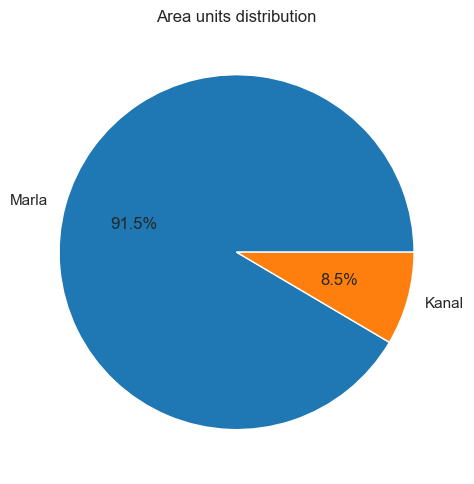

In [13]:
# Check what units exist in area column

#extract untis
real_estate['area_unit'] = real_estate['area'].str.extract(r'(Marla|Kanal|Sq\. Yd\.|Sq\. Ft\.)', expand=False)
#plot
plt.figure(figsize=(10, 5))
real_estate['area_unit'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Area units distribution')
real_estate.drop(columns=['area_unit'], inplace=True)
plt.tight_layout()
plt.savefig("../outputs/initial_eda_area_unit_distribution.png", dpi=150, bbox_inches='tight') 
plt.show()

In [14]:
# Check price distribution
print(f"\nZero prices  : {(real_estate['price'] == 0).sum()}")
print(f"Null prices  : {real_estate['price'].isnull().sum()}")


Zero prices  : 1
Null prices  : 0


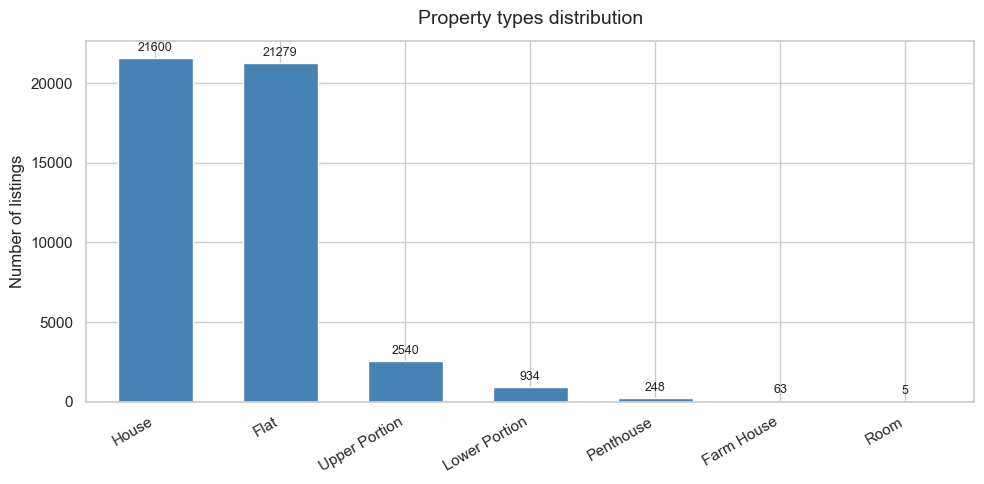

In [15]:
#property_types
data = real_estate['property_type'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

# Plot
data.plot(kind='bar', color='steelblue', width=0.6)

plt.title('Property types distribution', fontsize=14, pad=12)
plt.xlabel('')
plt.ylabel('Number of listings')

plt.xticks(rotation=30, ha='right')

# Add value labels on bars
ax = plt.gca()                  
ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/initial_eda_property_types.png", dpi=150, bbox_inches='tight')
plt.show()

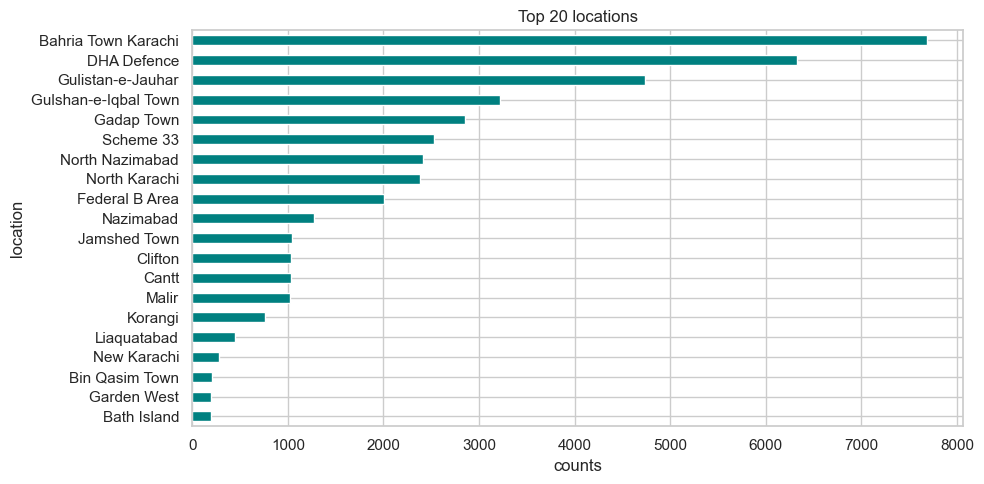

In [16]:
# Top areas by listing count
plt.figure(figsize=(10, 5))
real_estate['location'].value_counts().head(20).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Top 20 locations')
plt.xlabel("counts")
plt.tight_layout()
plt.savefig("../outputs/initial_eda_top20_locations.png", dpi=150, bbox_inches='tight') 
plt.show()

In [17]:
# Extract numeric value from area column
def clean_area(area_str):
    if pd.isna(area_str):
        return pd.NA
    
    area_str = str(area_str).strip().lower()
    
    # Extract number 
    match = re.search(r'([\d.]+)', area_str)
    if match:
        return float(match.group(1))
    return pd.NA

real_estate['area_numeric'] =real_estate['area'].apply(clean_area)

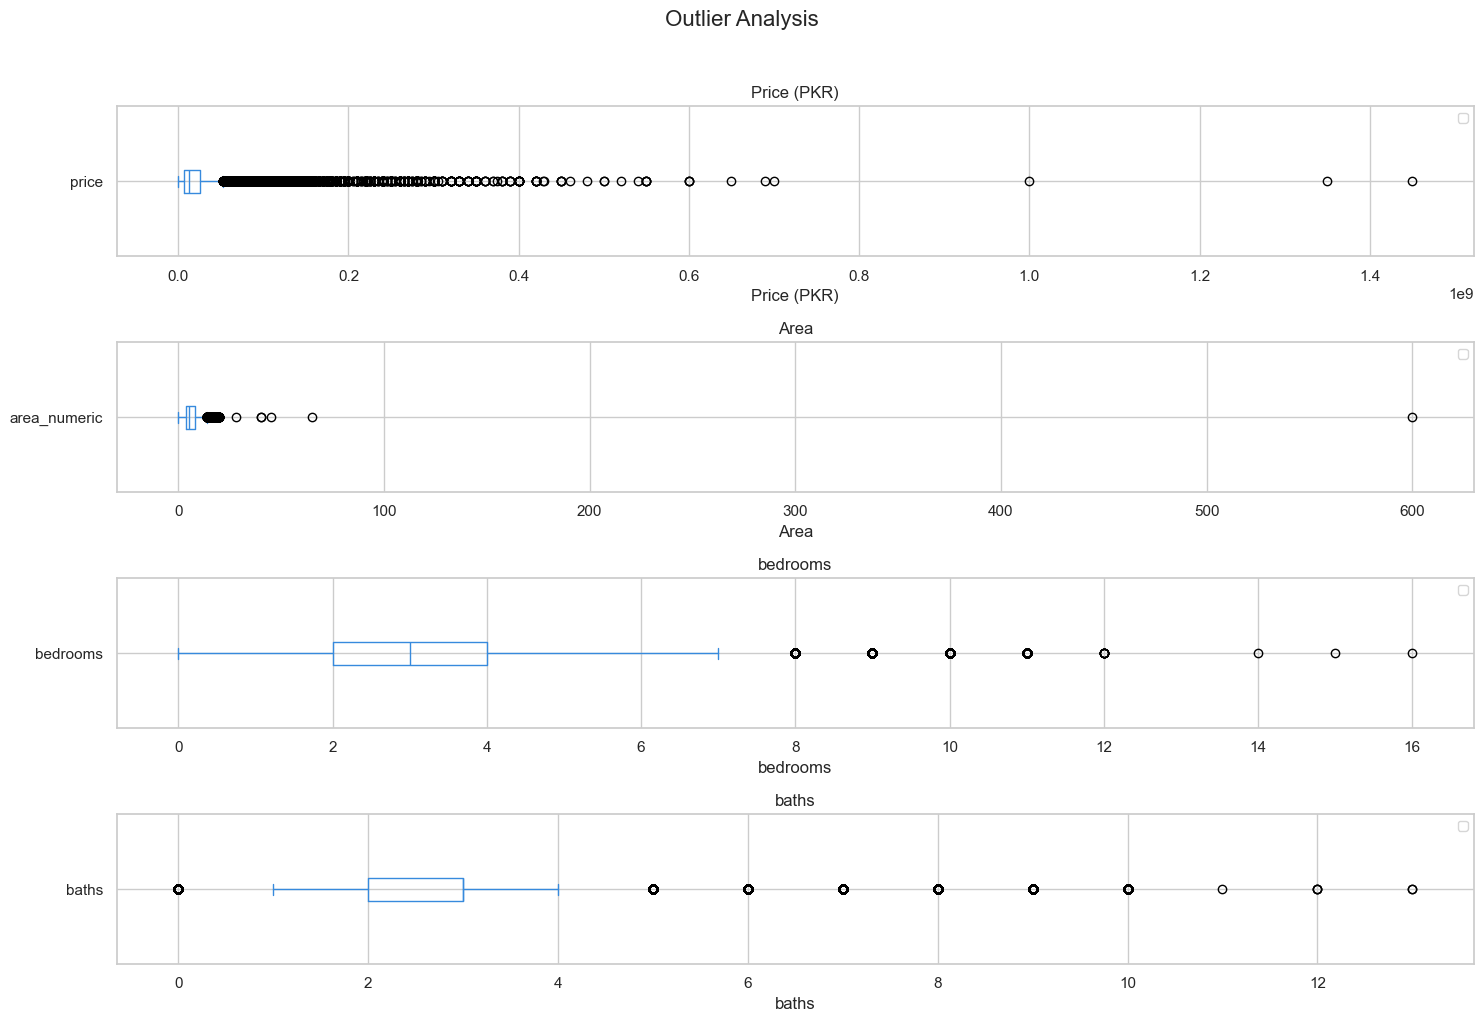

In [18]:
# outlier analysis
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
fig.suptitle('Outlier Analysis', fontsize=16, y=1.02)

cols = ['price', 'area_numeric','bedrooms','baths']
titles = ['Price (PKR)', 'Area','bedrooms','baths']

for ax, col, title in zip(axes.flatten(), cols, titles):
    real_estate[col].plot(kind='box', ax=ax, vert=False, color='#378ADD')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(title)   
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/uni_box_plot_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

real_estate.drop(columns=['area_numeric'], inplace=True)

-----------------------------------
<h4  style="font-family: 'Arial';"><b>Key Observation: </b></h4>
<p style="font-family: 'Arial';color: green; font-size:16px;"><i><b>Dataset Overview:</b>
The filtered dataset contains 46,669 rows and 17 columns, covering only Karachi For Sale listings. No duplicate rows were found, so no deduplication is needed.</i></p>
<h4 style="font-family: 'Arial';color:blue; font-size:16px;" ><b>Dirty Data:</b></h4>
<ul style="font-family: 'Arial';color: green; font-size:16px;"><i>
<li><b>price:</b> Price has no null values. Only 1 zero-price entry exists, which is invalid as a property cannot have a price of zero. That row must be dropped.</li>
 <li><b>bedrooms:</b>9.76% of rows have a value of 0, meaning the seller did not fill in this field. The distribution is slightly right-skewed, confirmed by the describe() statistics. These will be filled using group-wise median imputation, grouped by location and property_type.</li>   
<li><b>baths:</b> 21.77% of rows have a value of 0, meaning the seller did not fill in this field. The distribution is roughly symmetric. These will be filled using group-wise median imputation, grouped by location, property_type, and bedrooms. Dropping these rows is not an option as 21.77% is too large a share of the data to lose.</li>
<li><b>date_added:</b> Stored as string object and must be converted to datetime for any time-based analysis.
</li>
</ul></i> 

<h4 style="font-family: 'Arial';color:blue; font-size:16px;" ><b>Messy Data:</b></h4>
<ul style="font-family: 'Arial';color: green; font-size:16px;"><i>
<li><b>Outlier analysis (box plots — before removal):</b>Box plots confirmed extreme values in price and area. Price reached PKR 1.45 billion and area reached over 3.2 million sqft after unit conversion. These values are clearly impossible for a residential listing and will be treated in the cleaning step. </li>    
<li><b>area:</b>Only two area units exist in this dataset — Marla (91.5%) and Kanal (8.5%). All values must be converted to square feet for consistent analysis using Pakistani standard conversions: 1 Marla = 272.25 sqft and 1 Kanal = 5,445 sqft.. </li>
<li>
  <b>price,bedrooms,bathrooms and area:</b> Extreme values exist across all four columns, as seen in the outlier analysis. These will be treated using domain-based thresholds in the cleaning step.
</li> 
</ul>    
<h4 style="font-family: 'Arial'; color: blue; font-size:16px;">
<b>Columns To Drop:</b>
</h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li>
  <b>property_id, location_id, page_url:</b> Identifier and URL 
  columns — not needed for analysis.
</li>
<li>
  <b>city, province_name:</b> Constant values after Karachi filter 
  — provide no information.
</li>
<li>
  <b>agency, agent:</b> 44,000+ null values and not relevant 
  to price or area analysis.
</li>                                                            
</ul></i> 
<h4 style="font-family: 'Arial'; color: blue; font-size:16px;">
<b>Intial Eda:</b>
</h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>    
<li><b>Property Type Distribution:</b>
House (21,600) and Flat (21,279) together make up about 92% of all listings. Upper Portion, Lower Portion, and Penthouse account for the remaining 8%. This imbalance should be kept in mind during any property-type analysis, as results will be driven largely by houses and flats.</li>    
</i>
<li><b>Top Locations:</b>
Bahria Town Karachi (7,682 listings) and DHA Defence (6,327 listings) are the two most listed areas, together accounting for about 30% of the full dataset. This concentration means analysis results will be heavily influenced by these two areas.</li>
</ul></i>     

--------------------------------------------------------------------------

<h3 style="font-family: 'Times New Roman'; color: red;"><b>Data Cleaning</b></h3>

---
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Data Cleaning Goal: Improve data quality by handling missing values, correcting inconsistencies, removing duplicates and outliers, fixing data types, and preparing the dataset for reliable analysis and modeling.</b></i>
</p>

----

In [19]:
# Drop columns not needed for analysis
cols_to_drop = ['property_id', 'location_id', 'page_url','city', 'province_name', 'agency', 'agent', 'purpose']
real_estate.drop(columns=cols_to_drop, inplace=True)
print("Remaining columns:", real_estate.columns.tolist())
print("Shape:", real_estate.shape)

Remaining columns: ['property_type', 'price', 'location', 'latitude', 'longitude', 'baths', 'area', 'bedrooms', 'date_added']
Shape: (46669, 9)


In [20]:
# Remove invalid prices

#falback
real_estate = real_estate[real_estate['price'] > 0]
#check again
real_estate = real_estate.dropna(subset=['price'])
print("After price fix:", real_estate.shape)

After price fix: (46668, 9)


In [21]:
# Convert date_added to datetime
real_estate['date_added'] = pd.to_datetime(real_estate['date_added'],errors='coerce')
print(real_estate['date_added'].dtype)
print(real_estate['date_added'].head())

datetime64[us]
156   2019-06-20
157   2019-07-18
158   2018-10-20
159   2019-03-10
160   2019-07-18
Name: date_added, dtype: datetime64[us]


In [22]:
# Normalize area to sqft

def convert_to_sqft(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower().strip()
    num = re.sub(r'[^\d.]', '', val)
    try:
        num = float(num)
    except:
        return np.nan
    if 'kanal' in val:
        return num * 5445      
    elif 'marla' in val:
        return num * 272.25  
    elif 'sq. yd' in val or 'sqyd' in val:
        return num * 9
    elif 'sq. ft' in val or 'sqft' in val:
        return num
    return np.nan


In [23]:
real_estate['area_sqft'] = real_estate['area'].apply(convert_to_sqft)
real_estate.drop(columns=['area'], inplace=True)

# Remove impossible area values
real_estate = real_estate[
    (real_estate['area_sqft'] >= 80) & 
    (real_estate['area_sqft'] <= 50000)
]        

print("Area sqft sample:")
print(real_estate['area_sqft'].describe())

Area sqft sample:
count    46639.000000
mean      2290.221475
std       2327.090895
min        108.900000
25%       1143.450000
50%       1633.500000
75%       2613.600000
max      47916.000000
Name: area_sqft, dtype: float64


In [24]:
# Fixing bedrooms = 0 using group-wise median
real_estate['bedrooms'] = real_estate['bedrooms'].replace(0, np.nan)
#falback
real_estate['bedrooms'] = real_estate.groupby(['location', 'property_type'])['bedrooms'].transform(lambda x: x.fillna(x.median()))
#Remaining handle null values
real_estate['bedrooms'] = real_estate['bedrooms'].fillna(real_estate['bedrooms'].median())
real_estate['bedrooms'] = real_estate['bedrooms'].round().astype(int)
print("Bedrooms after fix:")
print(real_estate['bedrooms'].value_counts().sort_index())


Bedrooms after fix:
bedrooms
1       602
2     13730
3     16967
4      6009
5      3186
6      4514
7       634
8       489
9       218
10      152
11      127
12        8
14        1
15        1
16        1
Name: count, dtype: int64


In [25]:
# Fix baths = 0 using group-wise median
real_estate['baths'] = real_estate['baths'].replace(0, np.nan)

real_estate['baths'] = real_estate.groupby(['location', 'property_type', 'bedrooms'])['baths'].transform(lambda x: x.fillna(x.median()))
real_estate['baths'] = real_estate.groupby(['location', 'property_type'])['baths'].transform(lambda x: x.fillna(x.median()))
real_estate['baths'] = real_estate['baths'].fillna(real_estate['baths'].median())

real_estate['baths'] = real_estate['baths'].round().astype(int)
print("Baths after fix:")
print(real_estate['baths'].value_counts().sort_index())

Baths after fix:
baths
1      1261
2     13734
3     16555
4      6093
5      2905
6      4180
7       958
8       597
9       193
10      157
11        1
12        3
13        2
Name: count, dtype: int64


In [26]:
#Final null check
print("Remaining nulls:")
print(real_estate.isnull().sum())

real_estate = real_estate.dropna(subset=['price', 'area_sqft','location', 'bedrooms', 'baths'])
print("\nFinal clean shape:", real_estate.shape)
os.makedirs('../data/preprocessed', exist_ok=True)
real_estate.to_csv('../data/preprocessed/cleaned_listings.csv', index=False)
print("Saved successfully.")


Remaining nulls:
property_type    0
price            0
location         0
latitude         0
longitude        0
baths            0
bedrooms         0
date_added       0
area_sqft        0
dtype: int64

Final clean shape: (46639, 9)
Saved successfully.


<h4 style="font-family: 'Arial';"><b>Key Observations:</b></h4>

<h4 style="font-family: 'Arial'; color: blue; font-size:16px;">
<b>Summary of Cleaning Steps Performed:</b>
</h4>

<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>

<li>
  <b>Useless columns dropped:</b> property_id, location_id, page_url, 
  city, province_name, purpose, agency, and agent were removed. city and 
  province_name were constant after Karachi filter. agency and agent 
  had 44,000+ null values and are not relevant to price analysis.
</li>

<li>
  <b>Invalid prices removed:</b>  One row where price was zero was dropped, as it represents an incomplete listing that cannot be used in any price-based analysis.
</li>

<li>
  <b>date_added converted:</b> Column was stored as a string object 
  and has been converted to datetime format for consistency.
</li>

<li>
  <b>area converted to sqft:</b> Mixed units (Marla, Kanal) were 
  standardized to square feet using Pakistani standard conversions ( 
  1 Marla = 272.25 sqft and 1 Kanal = 5445 sqft). This ensures all 
  area-based calculations like price per sqft are consistent across 
  the dataset.
</li>

<li>
  <b>bedrooms imputed (9.76% zeros):</b> Zero values were replaced 
  with NaN and filled using group-wise median imputation, grouped by 
  location and property_type. This method was chosen over simple 
  median because bedroom counts vary significantly by area and 
  property type.for example,a DHA house and a Gulshan flat have different 
  typical bedroom counts. A global median would introduce bias. 
</li>

<li>
  <b>baths imputed (21.77% zeros):</b> Zero values were replaced 
  with NaN and filled using group-wise median imputation, grouped by 
  location, property_type, and bedrooms. Bathrooms correlate strongly 
  with bedroom count, so adding bedrooms as a grouping variable 
  produces more accurate fill values. Dropping was not possible as 
  21.77% represents too large a portion of the data. 
</li>

<li>
  <b>Outlier removal deferred:</b> Percentile outlier removal for price, area, and unrealistics bedrooms and baths treatment has not been applied at this stage. It will be handled properly in the EDA and feature engineering sections, so that removal decisions are based on evidence rather than assumption.
</li>

</ul></i>

<p style="font-family: 'Arial'; color: green; font-size:16px;">
<i><b>Rows Lost During Cleaning:</b>
About 30 rows (roughly 0.06% of the Karachi For Sale subset) were removed during the cleaning process,The core dataset is largely intact.</i>
</p>

<p style="font-family: 'Arial'; color: green; font-size:16px;">
<i><b>Final Dataset:</b>
After cleaning, the dataset contains 46639 rows and 9 columns. complete bedroom and bathroom values, and retains all columns needed for feature engineering and EDA.
</p>